# Collins 2026Feb beamtime (NAS-mounted)

Ingest (or refresh) the beamtime into the global `catalog.db`, then inspect samples, scans, and frame metadata. Optionally verify FITS mmap via one corrected image.

Requires `/Volumes/DATA/Collins/2026Feb` to exist on this machine.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from pyref.io import get_image_corrected, read_beamtime


In [2]:
BEAMTIME = Path("/Volumes/DATA/Collins/2026Feb")
assert BEAMTIME.is_dir(), f"Mount or fix path: {BEAMTIME}"

In [ ]:
view = read_beamtime(BEAMTIME, ingest=True)
print("catalog:", view.catalog_path)
print("samples:", view.entries.samples)
print("tags:", view.entries.tags)
print("scans (first 20):", view.entries.scans[:20])
print("frame rows:", view.frames.height)
view.frames.head(5)

Output()

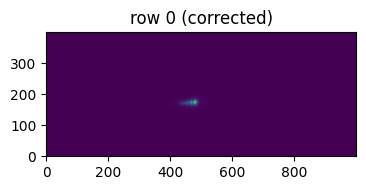

In [8]:
if view.frames.height > 0:
    img = get_image_corrected(view.frames, 20)
    arr = __import__("numpy").asarray(img)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(arr, origin="lower")
    ax.set_title("row 0 (corrected)")
    plt.show()
else:
    print("No frames; skip image check")
